In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nb
import nitools as nt
import cortico_cereb_connectivity.scripts.script_train_eval_models_bayes as scr
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as cs

In [4]:
traindata = gl.traindata_string(None)
cortex_roi = "Icosahedron1002"
method = 'L1regression'
ex = 'A-2_global'
stats = 'mean'
mean_mode = 'pos'

In [10]:
# Generate cifti_img and store in maps
cifti_img = cs.stats_weight_map_cortex(traindata = traindata,
                                       cortex_roi = cortex_roi,
                                       method = method,
                                       extension= ex,
                                       stats = stats,
                                       mean_mode = mean_mode)
fname = gl.conn_dir + f'/maps/{traindata}_{cortex_roi}_{method}_{stats}.pscalar.nii'
nb.save(cifti_img,fname)

In [11]:
# make the smoothed version of that map
fname = f'{traindata}_{cortex_roi}_{method}_{stats}.pscalar.nii'
oname = f'{traindata}_{cortex_roi}_{method}_{stats}.dscalar.nii'
cs.pscalar_to_smoothed_dscalar(fname,oname)

wb_command -cifti-smoothing 'temp.dscalar.nii' 4.0 0.0 COLUMN /cifs/diedrichsen/data/Cerebellum/connectivity/maps/MdWfIbDeHtNiSoScLa_Icosahedron1002_L1regression_mean.dscalar.nii -left-surface /cifs/diedrichsen/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-L_inflated.surf.gii -right-surface /cifs/diedrichsen/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-R_inflated.surf.gii


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/nilearn/plotting/surf_plotting.py:522: RuntimeWarning: invalid value encountered in divide
  data_copy /= (vmax - vmin)


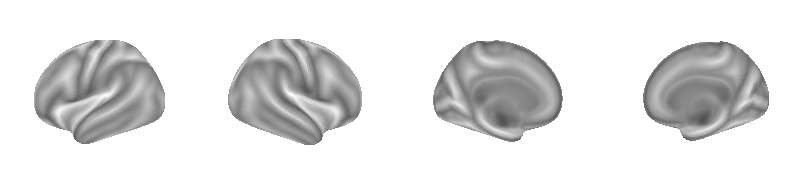

In [12]:
# Plot s inflated version of the cortical maps
cifti_img = nb.load(gl.conn_dir + f'/maps/{traindata}_{cortex_roi}_{method}_{stats}.pscalar.nii')
data = nt.surf_from_cifti(cifti_img)
fig, axes = plt.subplots(1, 4, subplot_kw={'projection': '3d'},figsize=(10, 8))
cs.plot_cortical_inflated(data=data,axes=axes)

In [6]:
mo, info = cs.get_model(traindata=traindata,
             cortex_roi=cortex_roi,
             method=method,
             extension='A0_global')

print(np.abs(mo.coef_).sum())

0.0
